<a href="https://colab.research.google.com/github/astha171206/react-python-fsd-v1/blob/main/Customer%20segmentation%20and%20churn%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


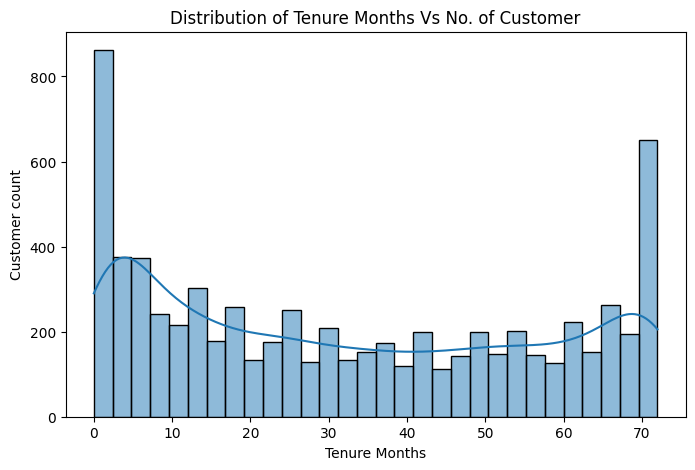

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months Vs No. of Customer')
plt.show()

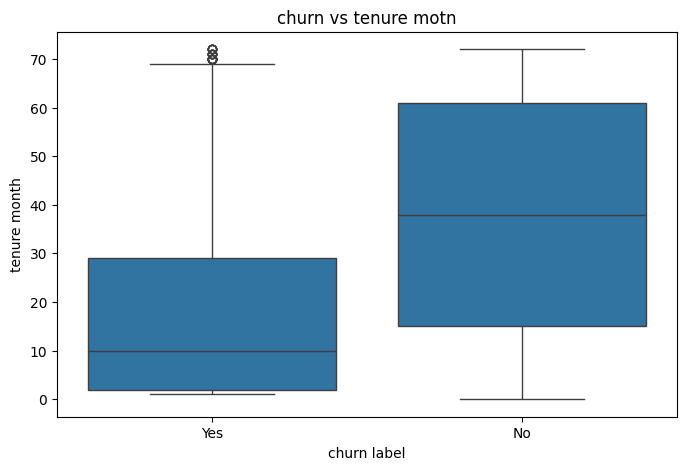

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df[df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


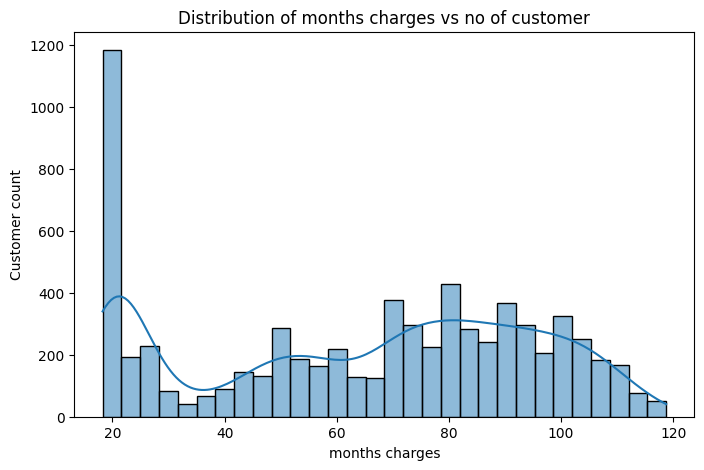

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [ ]:
df['Monthly Charges'].max()

118.75

In [ ]:
df['Monthly Charges'].min()

18.25

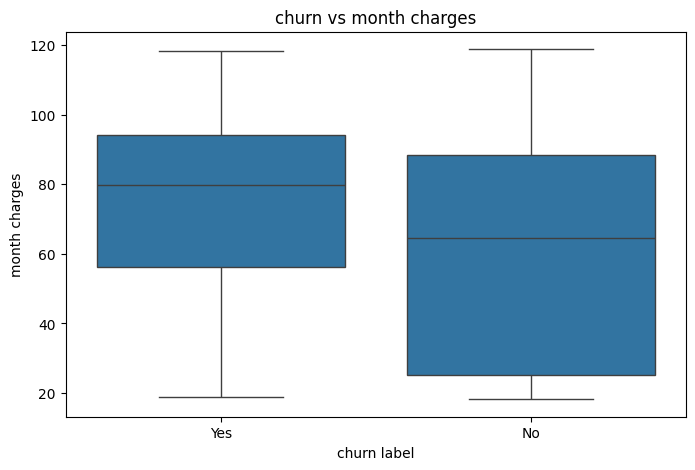

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('month charges')
plt.title('churn vs month charges')
plt.show()

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

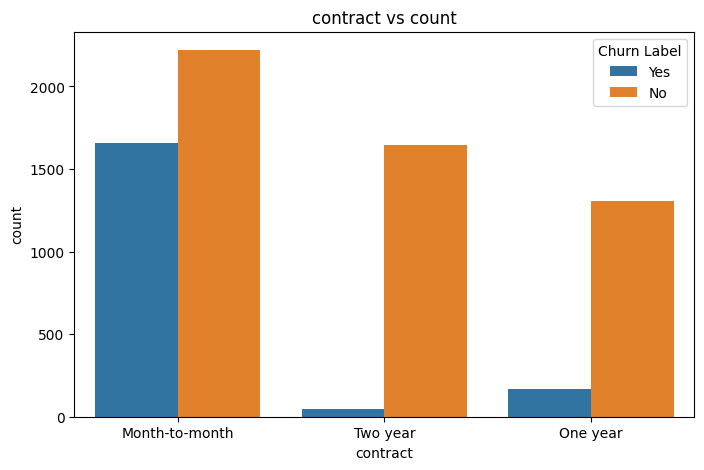

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('contract')
plt.ylabel('count')
plt.title('contract vs count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

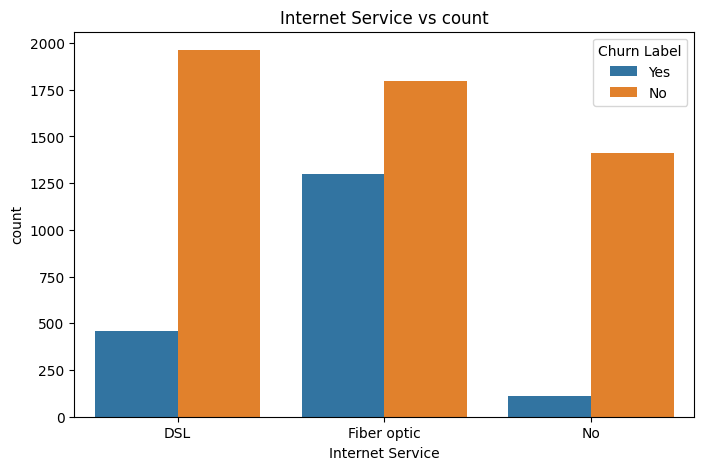

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

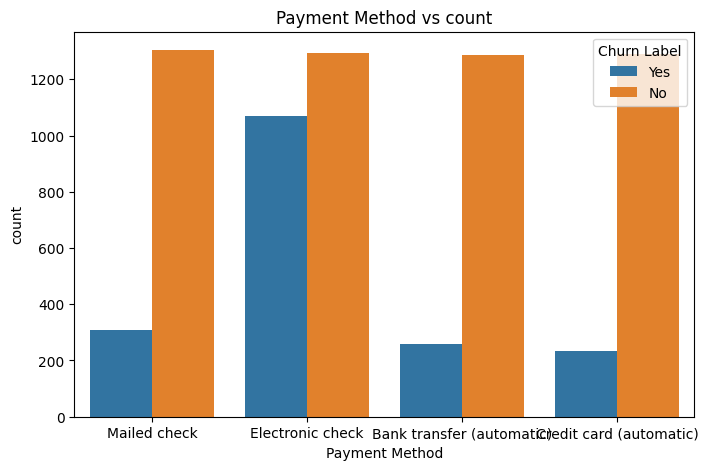

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

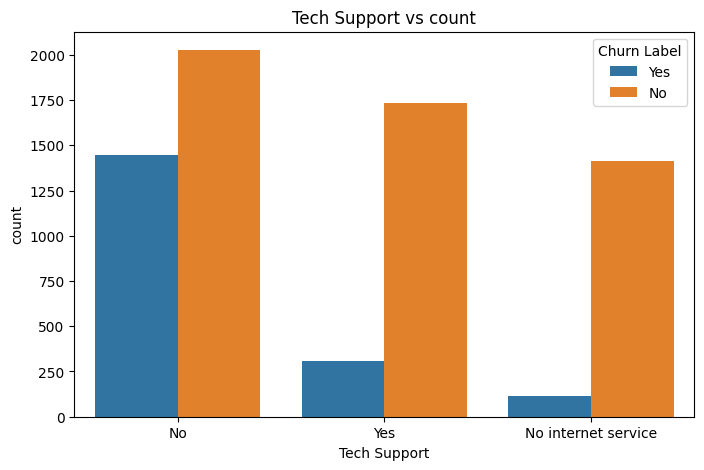

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [ ]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].dtype

dtype('float64')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
drop_columns=["CustomerID",'Count','Country','State','Zip Code','Lat Long','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [ ]:
df=df.drop(columns=drop_columns)

In [ ]:
df.shape

(7043, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Latitude           7043 non-null   float64
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [ ]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.head()

,Latitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,33.964131,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,34.059281,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,34.048013,8,99.65,820.50,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,34.062125,28,104.80,3046.05,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,34.039224,49,103.70,5036.30,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 1160)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Latitude           7043 non-null   float64
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.shape

(7043, 1160)

In [ ]:
x=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

In [ ]:
x.shape
y.shape

(7043,)

In [ ]:
print(x)

       Latitude  Tenure Months  Monthly Charges  Total Charges  City_Acton  \
0     33.964131              2            53.85         108.15       False   
1     34.059281              2            70.70         151.65       False   
2     34.048013              8            99.65         820.50       False   
3     34.062125             28           104.80        3046.05       False   
4     34.039224             49           103.70        5036.30       False   
...         ...            ...              ...            ...         ...   
7038  34.341737             72            21.15        1419.40       False   
7039  34.667815             24            84.80        1990.50       False   
7040  34.559882             72           103.20        7362.90       False   
7041  34.167800             11            29.60         346.45       False   
7042  34.424926             66           105.65        6844.50       False   

      City_Adelanto  City_Adin  City_Agoura Hills  City_Aguanga

In [ ]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


Machine learning implementation


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (x, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(5634, 1159)

In [ ]:
X_test.shape

(1409, 1159)

In [ ]:
y_train.shape

(5634,)

In [ ]:
y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf_model.predict(X_test)

In [ ]:
y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8005677785663591


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(y_test,y_pred)

In [ ]:
print(cm)

[[929  80]
 [201 199]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1009
           1       0.71      0.50      0.59       400

    accuracy                           0.80      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



*Approach-1 Handle class imbalance*


In [ ]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print(classification_report(y_test,y_pred_balanced))

0.808374733853797 [[920  89]
 [181 219]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1009
           1       0.71      0.55      0.62       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.80      0.81      0.80      1409



Approach-2 Hyperparameter tuning

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=200,random_state=22,class_weight='balanced')
rf_tuned.fit(X_train,y_train)
y_pred_tuned=rf_tuned.predict(X_test)

print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1009
           1       0.70      0.55      0.62       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



approach-3feature importance analysis

In [ ]:
import pandas as pd
feature_importance=pd.DataFrame({
    'feature':x.columns,
    'Importance':rf_tuned.feature_importances_
})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                     feature    Importance
1              Tenure Months  1.021734e-01
3              Total Charges  9.334749e-02
2            Monthly Charges  7.410302e-02
0                   Latitude  6.213776e-02
1154       Contract_Two year  3.942854e-02
...                      ...           ...
73    City_Belvedere Tiburon  1.173502e-06
419               City_Heber  1.153451e-06
395             City_Gridley  1.137805e-06
527               City_Laton  7.466871e-07
84        City_Big Bear Lake  5.023862e-07

[1159 rows x 2 columns]


In [ ]:
print(feature_importance.tail(15))

                    feature    Importance
339       City_Forest Falls  6.471494e-06
573         City_Lower Lake  6.429120e-06
95          City_Blocksburg  6.132587e-06
976          City_Stonyford  5.862177e-06
474          City_June Lake  5.499480e-06
596           City_Mariposa  5.291060e-06
282           City_Dunsmuir  4.507053e-06
964          City_Spreckels  2.774351e-06
900             City_Sanger  2.640256e-06
955             City_Sonora  1.933375e-06
73   City_Belvedere Tiburon  1.173502e-06
419              City_Heber  1.153451e-06
395            City_Gridley  1.137805e-06
527              City_Laton  7.466871e-07
84       City_Big Bear Lake  5.023862e-07


In [ ]:
x_selected=x.drop(['City_Big Bear Lake','City_Laton'],axis=1)

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split (x_selected, y, test_size=0.2, random_state=42)

In [ ]:
rf_selected=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)

print(classification_report(y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.71      0.55      0.61       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



approach 2 combination of trees and depth

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [ ]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
  for depth in n_estimators_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(X_train,y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({'trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1 Score':f1})
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')

In [ ]:
cv_accuracy=cross_val_score(final_rf,x,y,cv=5,scoring='accuracy')

In [ ]:
cv_accuracy

array([0.76224273, 0.76366217, 0.73740241, 0.74715909, 0.74431818])

In [ ]:
cv_accuracy.mean()

np.float64(0.7509569165752629)

In [ ]:
cv_recall=cross_val_score(final_rf,x,y,cv=5,scoring='recall')

In [ ]:
cv_recall.mean()


np.float64(0.8180714254992759)

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob1=rf_tuned.predict_proba(X_test)

In [ ]:
churn_prob=y_prob1[:,1]

In [ ]:
y_prob1=rf_tuned.predict_proba(X_test)

In [ ]:
y_prob=rf_tuned.predict_proba(x)

In [ ]:
churn_probability=y_prob[:,1]

In [ ]:
fpr,tpr,threshhold=roc_curve(y_test,churn_prob)
auc_score=roc_auc_score(y_test,churn_prob)
print(auc_score)

**customer segmentation**

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':x['Tenure Months'],
    'Monthly Charges':x['Monthly Charges'],
    'Total Charges':x['Total Charges'],
    'Churn Probability':churn_probability})

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.790
1,2,70.70,151.65,0.855
2,8,99.65,820.50,0.905
3,28,104.80,3046.05,0.760
4,49,103.70,5036.30,0.780
...,...,...,...,...
7038,72,21.15,1419.40,0.000
7039,24,84.80,1990.50,0.030
7040,72,103.20,7362.90,0.020
7041,11,29.60,346.45,0.085


Implementation of kmeans

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.61333037  1.3951138 ]
 [-1.23672422  0.19736523 -0.93887444  1.81345462  1.3951138 ]
 [-0.99240204  1.1595457  -0.64378925  1.96739636  1.3951138 ]
 [-0.17799476  1.33071079  0.3380854   1.52096533  1.3951138 ]
 [ 0.67713287  1.29415125  1.2161497   1.58254202  0.16903612]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

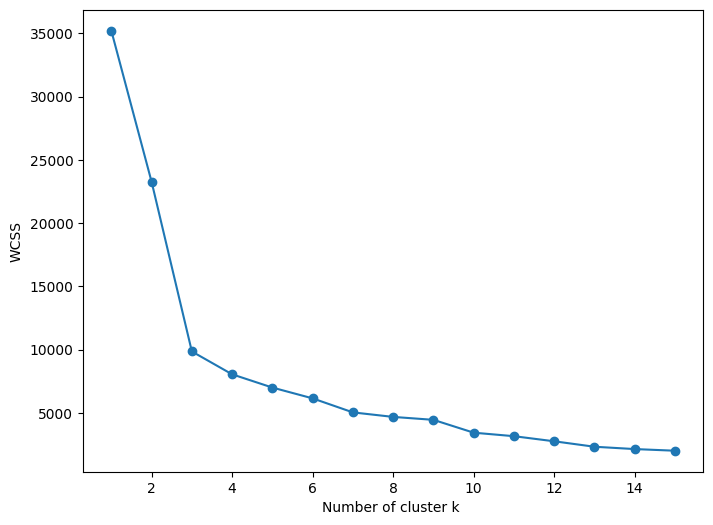

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3, random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.790,2
1,2,70.70,151.65,0.855,2
2,8,99.65,820.50,0.905,2
3,28,104.80,3046.05,0.760,2
4,49,103.70,5036.30,0.780,1
...,...,...,...,...,...
7038,72,21.15,1419.40,0.000,0
7039,24,84.80,1990.50,0.030,0
7040,72,103.20,7362.90,0.020,1
7041,11,29.60,346.45,0.085,0


In [ ]:
segmentation_data['Cluster']= clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.790,2
1,2,70.70,151.65,0.855,2
2,8,99.65,820.50,0.905,2
3,28,104.80,3046.05,0.760,2
4,49,103.70,5036.30,0.780,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.000,1
7039,24,84.80,1990.50,0.030,1
7040,72,103.20,7362.90,0.020,0
7041,11,29.60,346.45,0.085,1


In [ ]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,57.624101,90.168076,5184.309308,0.128847
1,27.004491,38.876287,959.678912,0.071674
2,11.255717,74.343009,908.520972,0.716913


In [ ]:
cluster_names={
0:'Budget Loyal Customers',
1:'High Risk New Customers',
2:'Loyal Premium CUstomers'

}

In [ ]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.790,2,Loyal Premium CUstomers
1,2,70.70,151.65,0.855,2,Loyal Premium CUstomers
2,8,99.65,820.50,0.905,2,Loyal Premium CUstomers
3,28,104.80,3046.05,0.760,2,Loyal Premium CUstomers
4,49,103.70,5036.30,0.780,0,Budget Loyal Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.000,1,High Risk New Customers
7039,24,84.80,1990.50,0.030,1,High Risk New Customers
7040,72,103.20,7362.90,0.020,0,Budget Loyal Customers
7041,11,29.60,346.45,0.085,1,High Risk New Customers


In [ ]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

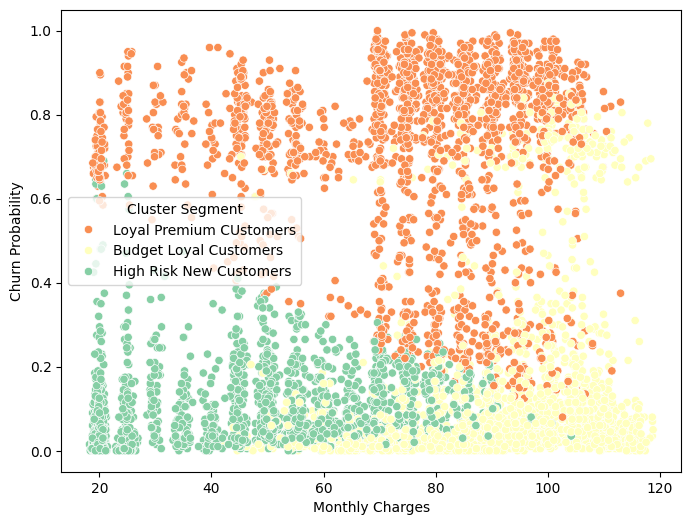

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

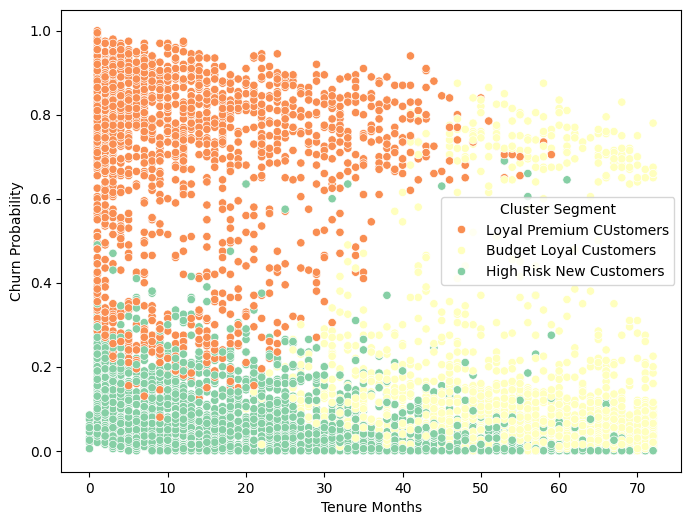

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

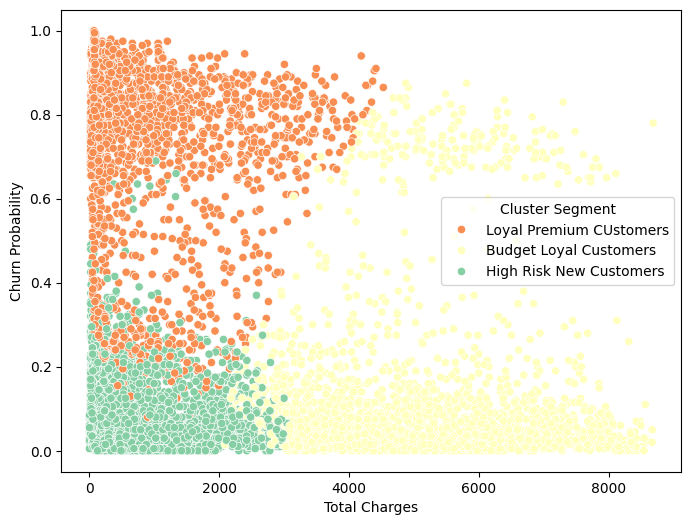

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')